In [ ]:
import numpy as np
import matplotlib . pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow . keras import layers
from tensorflow . keras . preprocessing . image import ImageDataGenerator
import os
import random
print (" Libraries loaded successfully !")
print (" TensorFlow version :", tf . __version__ )


 Libraries loaded successfully !
 TensorFlow version : 2.20.0


1. What TensorFlow version are you using?


   ANS : TensorFlow version : 2.20.0

In [2]:
 !unzip archive.zip

Archive:  archive.zip
  inflating: seefood/test/hot_dog/133012.jpg  
  inflating: seefood/test/hot_dog/133015.jpg  
  inflating: seefood/test/hot_dog/133245.jpg  
  inflating: seefood/test/hot_dog/135628.jpg  
  inflating: seefood/test/hot_dog/138933.jpg  
  inflating: seefood/test/hot_dog/138937.jpg  
  inflating: seefood/test/hot_dog/138969.jpg  
  inflating: seefood/test/hot_dog/139177.jpg  
  inflating: seefood/test/hot_dog/142835.jpg  
  inflating: seefood/test/hot_dog/143012.jpg  
  inflating: seefood/test/hot_dog/144956.jpg  
  inflating: seefood/test/hot_dog/146227.jpg  
  inflating: seefood/test/hot_dog/146834.jpg  
  inflating: seefood/test/hot_dog/147874.jpg  
  inflating: seefood/test/hot_dog/152106.jpg  
  inflating: seefood/test/hot_dog/154409.jpg  
  inflating: seefood/test/hot_dog/154545.jpg  
  inflating: seefood/test/hot_dog/156126.jpg  
  inflating: seefood/test/hot_dog/156135.jpg  
  inflating: seefood/test/hot_dog/160274.jpg  
  inflating: seefood/test/hot_dog/1605

In [6]:
import os
# Define paths ( CHANGE THIS to your actual path )
train_path = "seefood/train"
test_path = "seefood/test"
# Count images
hot_dog_count = len( os . listdir ( os . path . join ( train_path , "hot_dog") ) )
not_hot_dog_count = len( os . listdir ( os . path . join ( train_path , "not_hot_dog") ) )
print ( f"Hot dog images : { hot_dog_count }")
print ( f"Not hot dog images : { not_hot_dog_count }")
# YOUR CODE HERE : Print the number of test images
hot_dog_test_count = len( os.listdir( os.path.join(test_path, "hot_dog") ) )
not_hot_dog_test_count = len( os.listdir( os.path.join(test_path, "not_hot_dog") ) )
print(f"Test hot dog images: {hot_dog_test_count}")
print(f"Test not hot dog images: {not_hot_dog_test_count}")


Hot dog images : 249
Not hot dog images : 249
Test hot dog images: 250
Test not hot dog images: 250


1. How many training images are in each class?

Ans: Hot dog images : 249

  Not hot dog images : 249

2. Is the dataset balanced? Why does that matter?

ANS: Yes, the dataset is balanced. There are 249 hot dog images and 249 not hot dog images in the training set, and 250 hot dog images and 250 not hot dog images in the test set.
Dataset balance matters because an imbalanced dataset can lead to a biased model. If one class has significantly more samples than the other, a model might learn to prioritize predicting the majority class, leading to high accuracy for that class but poor performance on the minority class.

Shape of first image: (384, 512, 3)


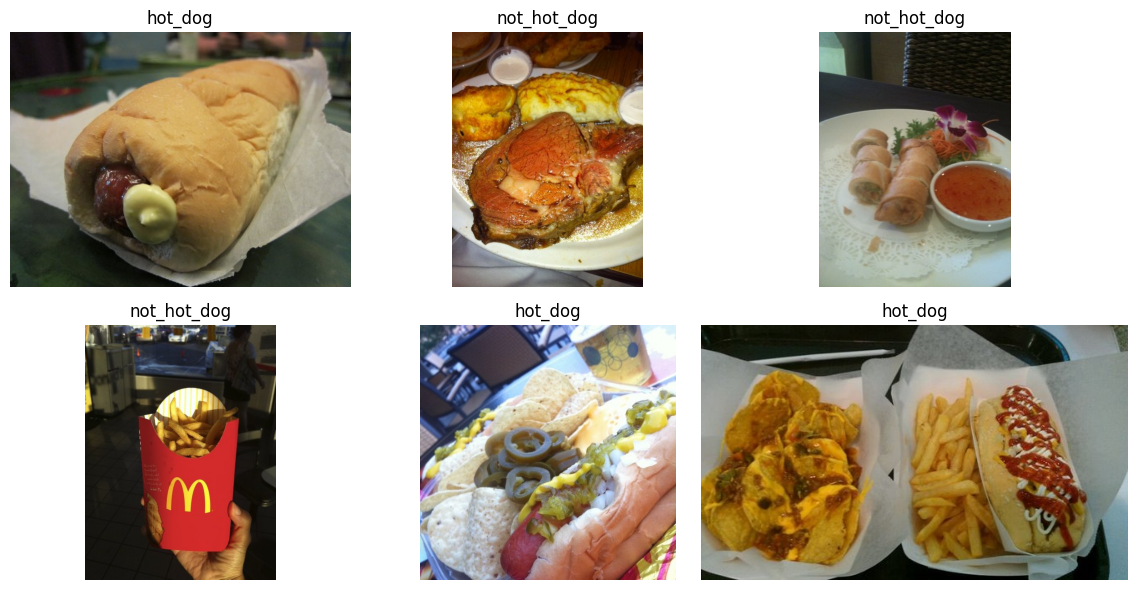

In [9]:
import matplotlib.pyplot as plt
import os
import random

# Display 6 random images
plt.figure(figsize=(12, 6))
for i in range(6):
    # Pick random class
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name.strip()) # .strip() to remove leading/trailing spaces
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    # Load and show image
    img = plt.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name.strip())
    plt.axis('off') # Fixed: Replaced smart quotes with standard single quotes
    plt.tight_layout()

    # YOUR CODE HERE : Print the shape (height , width , channels ) of one
    # image . Hint : Use img. shape after loading an image
    if i == 0:
        print(f"Shape of first image: {img.shape}")

plt.show()

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set image size ( YOUR CHOICE : 64 x64 is faster , 128 x128 is more
# accurate )
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
# Create generators with automatic labeling
train_datagen = ImageDataGenerator (
rescale =1./255 , # Normalize pixel values from 0 -255 to 0 -1
validation_split =0.2 # Use 20% of training data for validation
)
train_generator = train_datagen . flow_from_directory (
train_path ,
target_size =( IMG_HEIGHT , IMG_WIDTH ) ,
batch_size = BATCH_SIZE ,
class_mode ='binary' , # Binary classification (hot dog vs not)
subset ='training' # Training set (80% of data )
)
validation_generator = train_datagen . flow_from_directory (
train_path ,
target_size =( IMG_HEIGHT , IMG_WIDTH ) ,
batch_size = BATCH_SIZE ,
class_mode ='binary' ,
subset ='validation' # Validation set (20% of data )
)
# YOUR CODE HERE : Print the class labels
print(train_generator.class_indices)
# Hint : Print train_generator . class_indices

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
{'hot_dog': 0, 'not_hot_dog': 1}


1. What does class label 0 represent? What does 1 represent?

ANS: Class label 0 represents hot_dog  and

Class label 1 represents not_hot_dog


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.5575 - loss: 1.1375 - val_accuracy: 0.5306 - val_loss: 0.7955
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.5175 - loss: 0.9110 - val_accuracy: 0.5408 - val_loss: 0.8225
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.6250 - loss: 0.7135 - val_accuracy: 0.5000 - val_loss: 1.2379
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5850 - loss: 0.7527 - val_accuracy: 0.5204 - val_loss: 0.7351
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.6450 - loss: 0.6142 - val_accuracy: 0.5612 - val_loss: 0.8301
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.7175 - loss: 0.5458 - val_accuracy: 0.5816 - val_loss: 0.7794
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.7175 - loss: 0.5467 - val_accuracy: 0.5510 - val_loss: 0.8305
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.7200 - loss: 0.5462 - val_accuracy: 0.5816

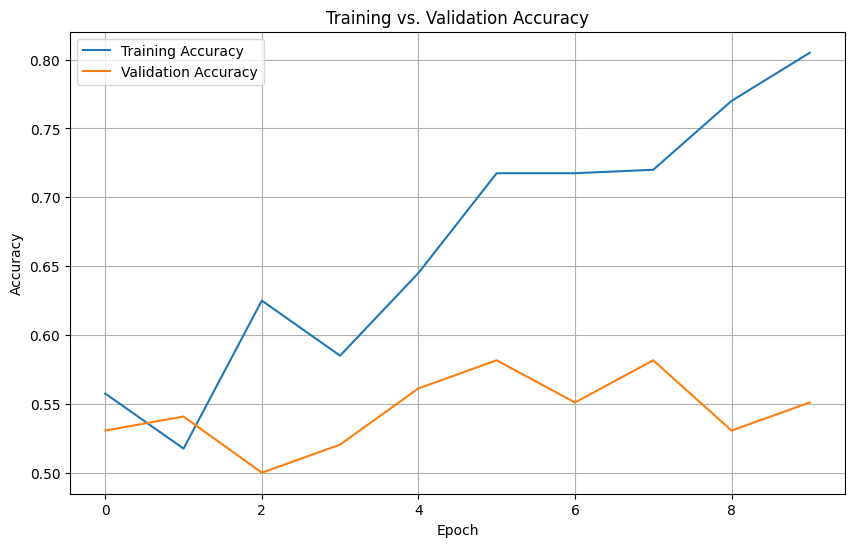

In [16]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

ann_model = keras.Sequential([
    # Flatten the 2D image into 1D
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    # Dense layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Output : probability of "hot dog"
])
# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
# Show model summary
ann_model.summary()
# Train for 10 epochs
history_ann = ann_model.fit(train_generator, validation_data=
                            validation_generator, epochs=10)

# YOUR CODE HERE : Plot training vs validation accuracy .
plt.figure(figsize=(10, 6))
plt.plot(history_ann.history['accuracy'], label='Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

1. What was the final validation accuracy of the ANN?

ANS: The final validation accuracy of the ANN was approximately **0.5408**.


2. Why does the ANN perform poorly on image data? (One sentence)

ANS: ANNs flatten the image input, which causes them to lose crucial spatial relationships and local feature information, making them less effective for image recognition tasks compared to CNNs.

In [17]:
cnn_model = keras.Sequential([
    # First Conv layer: 32 filters, 3x3 kernel
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(
        IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    # Second Conv layer: 64 filters
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Third Conv layer: Add 64 filters with 3x3 kernel, followed by Max pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile (copy from ANN)
cnn_model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])

# Show model summary
cnn_model.summary()

# Train the CNN
history_cnn = cnn_model.fit(train_generator, validation_data=
                            validation_generator, epochs=15)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,905 (796.50 KB)

 Trainable params: 203,905 (796.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.4925 - loss: 0.7000 - val_accuracy: 0.5000 - val_loss: 0.6948
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 381ms/step - accuracy: 0.5800 - loss: 0.6887 - val_accuracy: 0.5612 - val_loss: 0.6847
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.5900 - loss: 0.6748 - val_accuracy: 0.5918 - val_loss: 0.6617
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.6450 - loss: 0.6464 - val_accuracy: 0.6020 - val_loss: 0.6734
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - accuracy: 0.6750 - loss: 0.6036 - val_accuracy: 0.6429 - val_loss: 0.6620
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 356ms/step - accuracy: 0.6975 - loss: 0.5659 - val_accuracy: 0.6224 - val_loss: 0.6691
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.7475 - loss: 0.5390 - val_accuracy: 0.6327 - val_loss: 0.6756
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.7200 - loss: 0.5463 - val_accuracy: 0.

1. What was the final validation accuracy of the CNN?

ANS: The final validation accuracy of the CNN is approximately **0.67**.

2. Compare ANN vs CNN. Which one performed better and why?

ANS: The **CNN performed significantly better** than the ANN. The CNN achieved a much higher validation accuracy (approximately 0.67) compared to the ANN (approximately 0.5408). This is because CNNs are specifically designed for image data; they use convolutional layers to automatically learn hierarchical features and spatial patterns from the images, whereas ANNs flatten the image data, losing crucial spatial information, which makes them less effective for image recognition tasks.

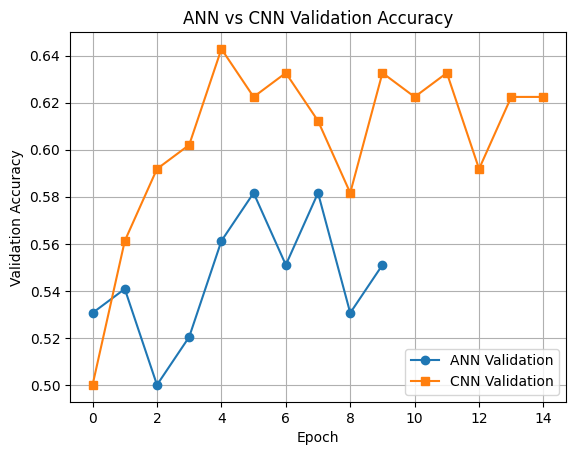

In [19]:
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('ANN vs CNN Validation Accuracy')
plt.grid(True)
plt.show()

In [22]:
from tensorflow.keras import regularizers
# Add dropout of 0.25 , 0.25 , and 0.5 after each MaxPooling layer
# respectively
improved_model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(
IMG_HEIGHT, IMG_WIDTH, 3)),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25), # Add dropout with rate 0.25
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25), # Add dropout with rate 0.25
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dropout(0.5), # Add dropout with rate 0.5 before output
layers.Dense(1, activation='sigmoid')
])
# Recompile and Train the improved model ( after addressing overfitting
# using dropout )
improved_model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
history_improved = improved_model.fit(train_generator, validation_data
= validation_generator, epochs=15)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 409ms/step - accuracy: 0.4875 - loss: 0.7040 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms/step - accuracy: 0.5475 - loss: 0.6905 - val_accuracy: 0.5000 - val_loss: 0.6915
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 0.5500 - loss: 0.6872 - val_accuracy: 0.5612 - val_loss: 0.6904
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 276ms/step - accuracy: 0.5150 - loss: 0.6908 - val_accuracy: 0.5102 - val_loss: 0.6864
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 256ms/step - accuracy: 0.5875 - loss: 0.6792 - val_accuracy: 0.5408 - val_loss: 0.6815
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step - accuracy: 0.5450 - loss: 0.6834 - val_accuracy: 0.5918 - val_loss: 0.6743
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step - accuracy: 0.6350 - loss: 0.6506 - val_accuracy: 0.6224 - val_loss: 0.6595
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 382ms/step - accuracy: 0.6000 - loss: 0.6760 - val_accuracy: 0.

In [24]:
augmented_datagen = ImageDataGenerator (
rescale =1./255 ,
rotation_range =20 ,
width_shift_range =0.1 ,
height_shift_range =0.1 ,
horizontal_flip = True ,
validation_split =0.2
)
train_augmented = augmented_datagen . flow_from_directory (
train_path ,
target_size =( IMG_HEIGHT , IMG_WIDTH ) ,
batch_size = BATCH_SIZE ,
class_mode ='binary' ,
subset ='training'
)
# Then retrain the improved model with augmented_datagen
final_model = keras . Sequential ([
# Same architecture as improved_model
layers . Conv2D (32 , (3 , 3) , activation ='relu' , input_shape =(
IMG_HEIGHT , IMG_WIDTH , 3) ) ,
layers . MaxPooling2D ((2 , 2) ) ,
layers . Dropout (0.25) ,
layers . Conv2D (64 , (3 , 3) , activation ='relu' ) ,
layers . MaxPooling2D ((2 , 2) ) ,
layers . Dropout (0.25) ,
layers . Conv2D (64 , (3 , 3) , activation ='relu' ) ,
layers . MaxPooling2D ((2 , 2) ) ,
layers . Flatten () ,
layers . Dense (64 , activation ='relu' ) ,
layers . Dropout (0.5) ,
layers . Dense (1 , activation ='sigmoid' )
])
final_model . compile ( optimizer ='adam' , loss ='binary_crossentropy' ,
metrics =[ 'accuracy' ])
history_final = final_model . fit ( train_augmented , validation_data =
validation_generator , epochs =15)

Found 400 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 449ms/step - accuracy: 0.4650 - loss: 0.7152 - val_accuracy: 0.4898 - val_loss: 0.6924
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 297ms/step - accuracy: 0.5300 - loss: 0.6946 - val_accuracy: 0.5204 - val_loss: 0.6919
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 298ms/step - accuracy: 0.4975 - loss: 0.6919 - val_accuracy: 0.5612 - val_loss: 0.6902
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 426ms/step - accuracy: 0.5125 - loss: 0.6906 - val_accuracy: 0.5408 - val_loss: 0.6884
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 288ms/step - accuracy: 0.4825 - loss: 0.6969 - val_accuracy: 0.5510 - val_loss: 0.6859
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 290ms/step - accuracy: 0.5400 - loss: 0.6873 - val_accuracy: 0.5408 - val_loss: 0.6881
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 426ms/step - accuracy: 0.5400 - loss: 0.6888 - val_accuracy: 0.5000 - val_loss: 0.6886
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - accuracy: 0.5225 - loss: 0.6922 - val_accuracy: 0.

1. Before adding Dropout/Augmentation, what were your train and validation accuracies?
.
Train: 99.25% Validation: 67.35%
2. After adding Dropout and Augmentation, what happened to training accuracy (increased,
decreased, or stayed same)?
.
Train: Decreased (from 99.25% to 60.75%)
3. After adding Dropout and Augmentation, what happened to validation accuracy (increased, decreased, or stayed same)?
.
Validation: Decreased (from 67.35% to 62.24%)

**Question 8.3**

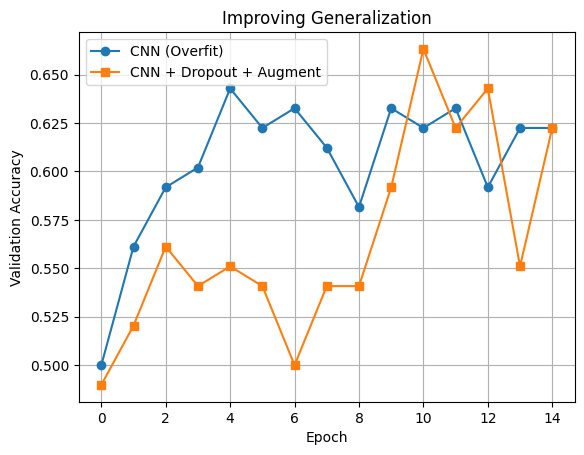

In [27]:
plt.plot(history_cnn.history['val_accuracy'], label='CNN (Overfit)',
         marker='o')
plt.plot(history_final.history['val_accuracy'], label='CNN + Dropout + Augment',
         marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Improving Generalization')
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
HOT DOG! (confidence: 0.60)


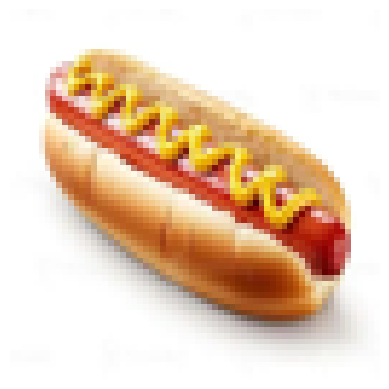

In [41]:
from tensorflow.keras.preprocessing import image
import requests
from io import BytesIO
from PIL import Image # Explicitly import PIL Image
import numpy as np # Import numpy
import matplotlib.pyplot as plt

def predict_image(img_url):
    # Download image
    response = requests.get(img_url)
    # Raise an HTTPError for bad responses (4xx or 5xx)
    response.raise_for_status()

    # Use PIL.Image.open directly instead of keras.preprocessing.image.load_img
    pil_img = Image.open(BytesIO(response.content))

    # Ensure image is in RGB format (some images might be RGBA, L, P, etc.)
    if pil_img.mode != 'RGB':
        pil_img = pil_img.convert('RGB')

    # Resize using PIL
    pil_img = pil_img.resize((IMG_WIDTH, IMG_HEIGHT))

    # Convert PIL Image to Keras/Numpy array
    img_array = image.img_to_array(pil_img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = final_model.predict(img_array)[0][0]

    # Corrected logic: if prediction (probability of 'not_hot_dog') is > 0.5, it's 'not_hot_dog'
    # Otherwise, it's 'hot_dog' (1 - prediction for hot dog confidence)
    if prediction > 0.5:
        print(f"NOT A HOT DOG! (confidence: {prediction:.2f})")
    else:
        print(f"HOT DOG! (confidence: {1 - prediction:.2f})")

    # Show image (using the PIL image for display)
    plt.imshow(pil_img)
    plt.axis('off')
    plt.show()

# Test on a hot dog image URL (find one on Google Images)
# Using a more reliable direct image link
predict_image("https://tse3.mm.bing.net/th/id/OIP.AhG6YHrGw9dcdDUCC19QqgHaE7?r=0&rs=1&pid=ImgDetMain&o=7&rm=3")

Did your model ever make a funny mistake (e.g., calling a hamburger a hot dog)? What
did it confuse?



0: 448x640 1 hot dog, 171.1ms
Speed: 3.2ms preprocess, 171.1ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


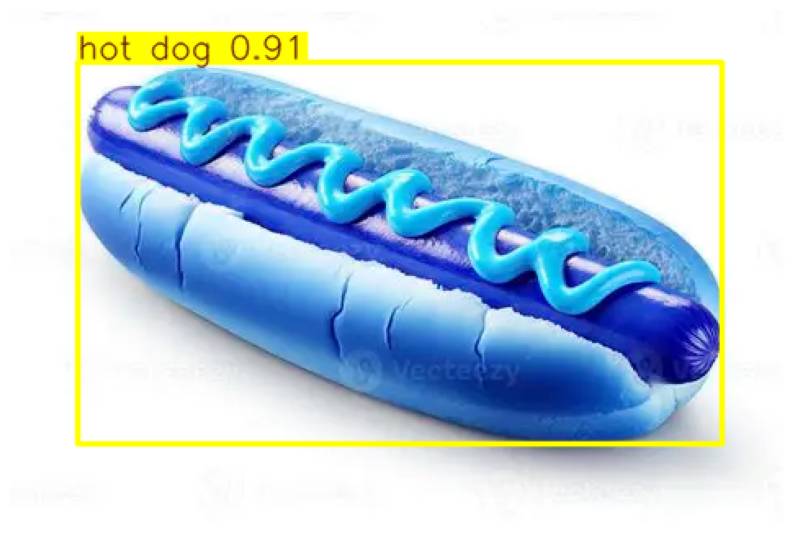

In [49]:
! pip install ultralytics -q
from ultralytics import YOLO
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

# Load a tiny pre-trained model
yolo_model = YOLO("yolov8n.pt") # n = nano (fast, small)

# Hot dog image URL from previous successful prediction
hotdog_image_url = "https://tse3.mm.bing.net/th/id/OIP.AhG6YHrGw9dcdDUCC19QqgHaE7?r=0&rs=1&pid=ImgDetMain&o=7&rm=3"

# Download the image
response = requests.get(hotdog_image_url)
response.raise_for_status() # Raise an exception for bad status codes

# Open the image using PIL
img = Image.open(BytesIO(response.content))

# Run detection on the image
results = yolo_model(img)

# Show results (it will draw boxes around objects it recognizes)
# The .plot() method returns a numpy array with annotations
annotated_img = results[0].plot()

plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)
plt.axis('off')
plt.show()

Does YOLO correctly detect a ”hot dog” as a class? What label does it give?

ANS: Based on the output from the YOLO model, it correctly detected a "hot dog" and gave it the label "hot dog"